# Stability solver 

this version replaces the previous shell integrator with Hydrodynamics class, which automatically computes the background ($v_0,w_0$ and their $\xi$-derivatives, plus the region boundaries) 

In [343]:
### imports
import numpy as np
from scipy.linalg import eig
import matplotlib.pyplot as plt
from HydrodynamicsFOPT import Hydrodynamics


In [ ]:
###########################################################################
##### WRAPPER to get the background profiles from the hydrodynamics class
###########################################################################

def background_from_hydro(alN, cb2=1/3, cs2=1/3, psiN=1.0, Tn=1.0):
    # alN = alpha_N : strength of the phase transition
    # cb2 = c_b^2 : speed of sound in the broken phase
    # cs2 = c_s^2 : speed of sound in the symmetric phase
    # psiN = psi_N : enthalpy ratio between the two phases
    # Tn = T_N : nucleation temperature
    h = Hydrodynamics(alN, cb2, cs2, psiN, Tn)

    # compute the velocity at LTE, which enforces entropy conservation at the wall
    vw_LTE_solns  = h.findVwLTE()
    if len(vw_LTE_solns) == 0:
        print("no matching solution for these parameters")
        return None
    else:
        print("found matching solution for LTE wall velocity: ", vw_LTE_solns[0])
        vw_LTE = vw_LTE_solns[0]
    m = h.findMatching(vw_LTE) # finds the matching solution for the LTE wall velocity

    m.setSplines()
    has_back = m.backWaveProfile is not None               # does the solution have a back rarefaction?
    xi_tail  = m.backWaveRange[0] if has_back else None    # rarefaction tail (hybrid)
    xi_w, xi_sh = vw_LTE, m.frontWaveRange[1] # wall and shock positions
    # get the exponents for the temperature profile
    # for bag EOS, c^2 = 1/3 ->  mu = 4
    mu_, nu_ = 1+1/cs2, 1+1/cb2

    def v0(x):  return m.velocityProfile(np.atleast_1d(x))
    def w0(x):  return m.enthalpyProfile(np.atleast_1d(x))

    # get the derivatives of the velocity and enthalpy profiles;
    # the 1 in the argument gets the first derivatives
    def v0p(x): return m.velocityProfile(np.atleast_1d(x), 1)
    def w0p(x): return m.enthalpyProfile(np.atleast_1d(x), 1)

    # get the thermodynamic profiles for temperature, entropy, and pressure
    # these depend on the bag equation of state, as defined in Espinosa paper (section 2)

    def T0(x):
        # from computeTemperatures in Hydro class
        x=np.atleast_1d(x)
        w=w0(x)                             #         back  T=Tn (w/psiN)^{1/nu}
        return np.where(x>=xi_w, Tn*w**(1/mu_), Tn*(w/psiN)**(1/nu_))

    # for bag EOS, s = w/T and p = w/4 - eps where eps is the vacuum energy offset of the broken phase (0 in the symmetric phase)
    def s0(x):  return w0(x)/T0(x)                         #   s = w/T
    eps = 0.75*alN                                         #   false-vacuum energy (w_N=1 norm):
                                                           #   alpha_N = eps/(a+ T_N^4)=eps/(3/4)
    def p0(x):                                             #   p = w/4 - eps_phase  (EOS eq 11,12,17)
        x=np.atleast_1d(x); w=w0(x)                        #   eps_+ = eps (symmetric, ahead+shell)
        # if in broken phase, subtract the vacuum offset
        return np.where(x>=xi_w, w/4.0 - eps, w/4.0)       #   eps_- = 0  (broken, behind wall)


    return dict(has_back=has_back, xi_tail=xi_tail, xi_w=xi_w, xi_sh=xi_sh,
                v0=v0, w0=w0, v0p=v0p, w0p=w0p, T0=T0, s0=s0, p0=p0,
                wm=m.wm, wp=m.wp, vp=m.vp, vm=m.vm, Tp=m.Tp, Tm=m.Tm)


In [ ]:
###########################################################################
##### Function to build the eigenvalue problem matrices for the perturbations
###########################################################################

def build(bg, L=8.0, n2_core=30, n2_raref=30, n1=60, xi_min=1e-2):
    ### NOTE: this currently only works for deflagration and hybrid solutions

    # n2_core = number of grid points in the at-rest core of region 2
    # n2_raref = number of grid points in the rarefaction of region 2 (if present)
    # n1 = number of grid points in region 1 (spans from the wall to the shock)
    # xi_min = minimum xi value for the grid (to avoid singularity at xi=0)

    # get the wall and shock positions from the background solution
    xi_w, xi_sh = bg['xi_w'], bg['xi_sh']
    # region-2 grid runs from a small xi_min through the at-rest core (and, for a hybrid,
    # the rarefaction) up to the wall. Core and rarefaction get separate point counts so the
    # thin rarefaction is resolved. For a deflagration region 2 is all at-rest core.
    if bg['has_back']: # if there is a rarefaction, split the region-2 grid into core and rarefaction
        # no endpoint for the core so that the last point is at the rarefaction tail,
        # which is the first point of the rarefaction grid.
        core  = np.linspace(xi_min, bg['xi_tail'], n2_core, endpoint=False)
        raref = np.linspace(bg['xi_tail'], xi_w, n2_raref)
        xg2   = np.concatenate([core,raref])
    else:
        xg2=np.linspace(xi_min, xi_w, n2_core)
    n2=xg2.size
    xg1=np.linspace(xi_w,xi_sh,n1)

    # build the combined xi grid
    xi=np.concatenate([xg2,xg1]); Ng=n2+n1
    iw_m=n2-1; iw_p=n2; ish=Ng-1

    # get the background profiles and their derivatives at the grid points
    xs=xi.copy()
    xs[:n2]=np.minimum(xg2, xi_w-1e-9)     # region 2: broken side
    xs[n2:]=np.maximum(xg1, xi_w+1e-9)     # region 1: shell side (unbroken phase) (FIXED INDEXING)
    v0=bg['v0'](xs); w0=bg['w0'](xs); v0p=bg['v0p'](xs); w0p=bg['w0p'](xs)
    p0=bg['p0'](xs); s0=bg['s0'](xs); g0=1/np.sqrt(1-v0**2); g0p=g0**3*v0*v0p

    # define the number of fields and total number of equations;
    # define the indices for the wall and shock matching conditions
    # NF = 3 because we have three perturbation fields: f, g, and V;
    # add 2 for the wall and shock closure conditions
    NF=3; Ntot=NF*Ng+2; ikw=NF*Ng; iksh=NF*Ng+1
    def idx(i,f): return NF*i+f

    # initialize the matrices and filled array
    A=np.zeros((Ntot,Ntot)); B=np.zeros((Ntot,Ntot)); filled=np.zeros(Ntot,bool)

    # define the coefficients for the bulk equation coefficient arrays, evaluated at each grid point
    def C(i):
        gg=g0[i];v=v0[i];w=w0[i]
        return dict(R1=4*gg**2*v,R2=gg**2*w*(2*gg**2*v**2+1),R3=4*gg**2*v**2+1,R4=2*w*gg**4*v,
                    R5=4*gg**2*v**2,R7=w*gg**2*v,T1=4*gg**2-1,T2=2*w*gg**4*v,T3=4*gg**2*v,
                    T4=gg**2*w*(2*gg**2*v**2+1),T5=w*gg**2)

    # define the bulk equations for the perturbations, constructed with the coeff arrays
    def bulk(i,back=False):
        xii=xi[i];Ci=C(i)
        if back: h=xi[i]-xi[i-1]; st=[(i,1.5/h),(i-1,-2.0/h),(i-2,0.5/h)]
        else: hh=0.5*(xi[i+1]-xi[i-1]); st=[(i+1,1.0/(2*hh)),(i-1,-1.0/(2*hh))]
        def Bf(r,fld,Cn,pre):
            # Bf = B flux; stamps the terms of the form pre * partial_xi ( C field) where C depends on on the bkg
            for (j,wt) in st: B[r,idx(j,fld)]+=-pre*C(j)[Cn]*wt
        def Bd(r,fld,cv):
            # Bd = B derivative; stamps terms of the form cv * partial_xi (field) where the coefficient is a constant
            for (j,wt) in st: B[r,idx(j,fld)]+=-cv*wt

        # Aa = A algebraic; stamps terms of the form c * field where the coefficient depends on the background
        def Aa(r,fld,c): A[r,idx(i,fld)]+=c

        # Ba = B algebraic; stamps terms of the form c * field where the coefficient is a constant
        def Ba(r,fld,c): B[r,idx(i,fld)]+=-c

        # ============================================================
        # TIMELIKE equation (TE)  ->  row = idx(i,0)  [f-slot]
        #   alpha*(T1 f + T2 g) = d/dxi(-xi*T1 f - xi*T2 g + T3 f + T4 g)
        #                          + (2/xi)(T3 f + T4 g) - (l(l+1)/xi) T5 V
        # ============================================================
        r=idx(i,0)
        Aa(r,0,Ci['T1']); Aa(r,1,Ci['T2'])                      # A: alpha*(T1*f + T2*g)
        Bf(r,0,'T1',-xii); Bf(r,1,'T2',-xii)                    # B: d/dxi(-xi*T1*f), d/dxi(-xi*T2*g)
        Bf(r,0,'T3',1.);   Bf(r,1,'T4',1.)                      # B: d/dxi(T3*f),     d/dxi(T4*g)
        Ba(r,0,(2/xii)*Ci['T3']); Ba(r,1,(2/xii)*Ci['T4'])      # B: (2/xi)*T3*f,     (2/xi)*T4*g
        Ba(r,2,-(L*(L+1)/xii)*Ci['T5'])                         # B: -(l(l+1)/xi)*T5*V  (angular coupling piece)
        filled[r]=True

        # ============================================================
        # RADIAL equation (RE)  ->  row = idx(i,1)  [g-slot]
        #   alpha*(R1 f + R2 g) = d/dxi(-xi*R1 f - xi*R2 g + R3 f + R4 g)
        #                          + (2/xi)(R5 f + R4 g) - (l(l+1)/xi) R7 V
        # ============================================================
        r=idx(i,1)
        Aa(r,0,Ci['R1']); Aa(r,1,Ci['R2'])                      # A: alpha*(R1*f + R2*g)
        Bf(r,0,'R1',-xii); Bf(r,1,'R2',-xii)                    # B: d/dxi(-xi*R1*f), d/dxi(-xi*R2*g)
        Bf(r,0,'R3',1.);   Bf(r,1,'R4',1.)                      # B: d/dxi(R3*f),     d/dxi(R4*g)
        Ba(r,0,(2/xii)*Ci['R5']); Ba(r,1,(2/xii)*Ci['R4'])      # B: (2/xi)*R5*f,     (2/xi)*R4*g
        Ba(r,2,-(L*(L+1)/xii)*Ci['R7'])                         # B: -(l(l+1)/xi)*R7*V  (angular coupling)
        filled[r]=True

        # ============================================================
        # ANGULAR equation (AE)  ->  row = idx(i,2)  [V-slot]
        #   alpha*(Pa V) = Pb V + Pc V' + (1/xi) f
        #   coefficients carry background DERIVATIVES (w0', v0', g0'):
        #     Pa = w0 g0^2
        #     Pb = (w0 g0^2 v0)' - xi (w0 g0^2)' + (3/xi) w0 g0^2 v0
        #     Pc = w0 g0^2 (v0 - xi)
        # ============================================================
        wg2  = w0[i]*g0[i]**2                                    # w0 * g0^2
        wg2p = w0p[i]*g0[i]**2 + w0[i]*2*g0[i]*g0p[i]            # (w0 g0^2)'     -- product rule
        wg2v = w0[i]*g0[i]**2*v0[i]                              # w0 g0^2 v0
        wg2vp= wg2p*v0[i] + wg2*v0p[i]                           # (w0 g0^2 v0)'  -- product rule
        Pa = wg2
        Pb = wg2vp - xii*wg2p + (3/xii)*wg2v
        Pc = wg2*(v0[i]-xii)
        r=idx(i,2)
        Aa(r,2,Pa)                                              # A: alpha*Pa*V
        Ba(r,2,Pb)                                              # B: Pb*V        (algebraic)
        Bd(r,2,Pc)                                              # B: Pc*V'       (coeff * derivative)
        Ba(r,0,1/xii)                                           # B: (1/xi)*f    (source from pressure)
        filled[r]=True


    # ============================================================
    # INNER-EDGE REGULARITY  ->  rows idx(0,0), idx(0,1), idx(0,2)  [point 0 = innermost]
    #   Select the REGULAR Frobenius branch at the origin.
    #   From acoustic j_l in the uniform core:  pressure f ~ xi^l ,  velocities g,V ~ xi^{l-1}.
    #   Discrete form: enforce the power law across the first two points,
    #     field_0 = (xi_0 / xi_1)^power * field_1
    #   => row:  1.0*field_0 - (xi_0/xi_1)^power * field_1 = 0   (just pure B, no alpha)
    # ============================================================

    x0,x1 = xi[0], xi[1]
    pf = (x0/x1)**L          # pressure power:   f ~ xi^l
    pv = (x0/x1)**(L-1)      # velocity power:   g,V ~ xi^{l-1}   (l>=1)
    for f,pw in ((0,pf),(1,pv),(2,pv)):          # f-slot uses pf; g,V-slots use pv
        r=idx(0,f)
        B[r,idx(0,f)] += 1.0                      # B: +1 * field_0
        B[r,idx(1,f)] += -pw                      # B: -(xi_0/xi_1)^power * field_1
        filled[r]=True

    # ============================================================
    # BULK STAMPING LOOPS  (call bulk(i) -> stamps TE/RE/AE at point i)
    # ============================================================
    # Region 2 (behind wall): points 1 .. n2-1.
    #   point 0     -> inner regularity (above), NOT bulk
    #   point iw_m  -> wall-minus; uses ONE-SIDED backward diff (back=True)
    #                  so stencil doesn't cross  the wall discontinuity
    for i in range(1, n2):
        bulk(i, back=(i==iw_m))                   # centered, except backward at the wall-minus point

    # Region 1 (shell): interior points n2+1 .. Ng-2.
    #   point n2     (iw_p / wall-plus) -> junction conditions, NOT bulk
    #   point Ng-1   (shock)            -> shock conditions,    NOT bulk
    for i in range(n2+1, Ng-1):
        bulk(i, back=False)                       # all centered (region 1 is smooth)



    def Tc(i):
        # background stress-energy T^{mu nu}_0 COMPONENTS at point i
        w=w0[i];v=v0[i];g=g0[i];p=p0[i];return dict(T00=w*g**2-p,T0r=w*g**2*v,Trr=w*g**2*v**2+p)
    def Td(i):
        # d/dxi of those stress-energy components: (T^{mu nu}_0)'   -- needed for Taylor-shift terms
        w=w0[i];v=v0[i];g=g0[i];wp=w0p[i];vp=v0p[i];gp=g0p[i];pp=w0p[i]/4
        d=wp*g**2+w*2*g*gp # d(w*g**2)/dxi = w'*g^2 + w*2*g*g'
        return dict(T00=d-pp,T0r=d*v+w*g**2*vp,Trr=d*v**2+w*g**2*2*v*vp+pp)
    def kap(i,k,xsl):
        # get kappa coeffients for the matching conditions at the wall

        g=g0[i];v=v0[i];w=w0[i]
        a=4*g**2-1;b=2*w*g**4*v;c=4*g**2*v;d=g**2*w*(2*g**2*v**2+1);e=4*g**2*v**2+1;f2=2*w*g**4*v
        if k=='TE':return dict(f=-xsl*a+c,g=-xsl*b+d,V=0.)
        if k=='RE':return dict(f=-xsl*c+e,g=-xsl*d+f2,V=0.)
        if k=='theta':return dict(f=0.,g=0.,V=(v-xsl)*w*g**2)
        if k=='ENT':
            sr=s0[i];j0f=3*g*sr/w;j0g=g**3*v*sr;jrf=3*g*v*sr/w;jrg=sr*g**3
            return dict(f=-xsl*j0f+jrf,g=-xsl*j0g+jrg,V=0.)
    def mu_a(i,k):
        # mu_a coefficients for the junction conditions
        T=Tc(i);return {'TE':-T['T00'],'RE':-T['T0r'],'theta':0.,'ENT':-g0[i]*s0[i]}[k]
    def mu_0(i,k,xsl):
        # mu_0 coefficients for the junction conditions
        T=Tc(i);D=Td(i)  # get tensor components and their xi derivatives
        if k=='TE':return -T['T00']+D['T0r']-xsl*D['T00']
        if k=='RE':return -T['T0r']+D['Trr']-xsl*D['T0r']
        if k=='theta':return -p0[i]/xsl
        if k=='ENT':
            g=g0[i];v=v0[i];sr=s0[i];vp=v0p[i];gp=g0p[i];sp=w0p[i]
            return -g*sr+((gp*v+g*vp)*sr+g*v*sp)-xsl*(gp*sr+g*sp)

    def junc(row,ip,im,xsl,kc,k):
        # stamp the wall junction conditions based on the coefficients from kap, mu_a, and mu_0
        kp=kap(ip,k,xsl);km=kap(im,k,xsl)
        for f,c in (('f',0),('g',1),('V',2)):
            B[row,idx(ip,c)]+=-kp[f];B[row,idx(im,c)]+=+km[f]
        A[row,kc]+=(mu_a(ip,k)-mu_a(im,k));B[row,kc]+=-(mu_0(ip,k,xsl)-mu_0(im,k,xsl));filled[row]=True

    ## stamp the wall junction conditions at the wall point (iw_p) using the wall-minus point (iw_m)
    ## for the wall, all 4 conditions can use the template
    junc(idx(iw_p,0),iw_p,iw_m,xi_w,ikw,'TE');junc(idx(iw_p,1),iw_p,iw_m,xi_w,ikw,'RE')
    junc(idx(iw_p,2),iw_p,iw_m,xi_w,ikw,'theta');junc(ikw,iw_p,iw_m,xi_w,ikw,'ENT')

    ## stamp the shock junction conditions at the shock point (ish) using the wall-plus point (iw_p)
    ## here, only 3 conditions can use the pre-defined template, the 3rd kinematic condition needs a separate treatment
    def sj(row,k):
        # stamp the shock junction conditions based on the coefficients from kap, mu_a, and mu_0
        i=ish;kp=kap(i,k,xi_sh)
        for f,c in (('f',0),('g',1),('V',2)): B[row,idx(i,c)]+=-(-kp[f])
        A[row,iksh]+=-(mu_a(i,k));B[row,iksh]+=-(-mu_0(i,k,xi_sh));filled[row]=True
    sj(idx(ish,0),'TE');sj(idx(ish,1),'RE');sj(idx(ish,2),'theta')

    # enforce the shock KINEMATIC condition
    i=ish;v=v0[i];den=(1-xi[i]*v)**2;m_=(xi[i]-v)/(1-xi[i]*v)
    Sk=m_+xi[i]*(1-v**2)/den;Sg=xi[i]*(1-xi[i]**2)/den
    B[iksh,iksh]+=Sk;B[iksh,idx(ish,1)]+=-Sg;filled[iksh]=True

    # return the matrices and other relevant info.
    return dict(A=A,B=B,filled=filled,Ntot=Ntot,xi=xi,n2=n2,n1=n1,NF=NF,
                iw_p=iw_p,ish=ish,ikw=ikw,iksh=iksh,v0=v0,w0=w0,xi_w=xi_w,xi_sh=xi_sh)

# define eigenproblem solver
def solve(M, tol=1e6):
    al=eig(M['B'],M['A'],right=False); fin=al[np.isfinite(al)]; return fin[np.abs(fin)<tol]


found matching solution for LTE wall velocity:  0.29958806514240965
has_back=False  tail=— (deflagration)  wall=0.2996  shock=0.5774
guards OK: square, row bijection, surface-amplitude columns zero in bulk


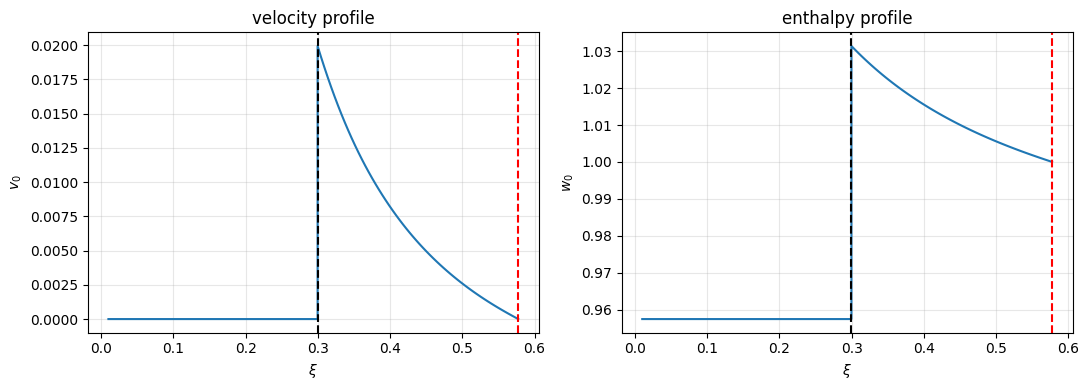

In [ ]:
###########################################################################
##### Compute spectrum for a given background solution and ell-value
###########################################################################

### DEFLAGRATION SOLUTION
PSI_N_TEST = 0.95
ALN_TEST = 0.017
# NB: should yield vw = 0.3
#########################

# #### HYBRID SOLUTION
# PSI_N_TEST = 0.91
# ALN_TEST = 0.04
#########################

L_TEST = 4

bg = background_from_hydro(alN=ALN_TEST,  psiN= PSI_N_TEST)
tail = f"{bg['xi_tail']:.4f}" if bg['has_back'] else '— (deflagration)'
print(f"has_back={bg['has_back']}  tail={tail}  wall={bg['xi_w']:.4f}  shock={bg['xi_sh']:.4f}")

M = build(bg, L=L_TEST, n2_core=60, n2_raref=40, n1=60)
assert M['filled'].all(), f"unfilled rows: {np.where(~M['filled'])[0]}"
NF=M['NF']; ikw,iksh=M['ikw'],M['iksh']
n2=M['n2']; interior=[NF*i+f for i in range(2,n2-1) for f in range(3)]
assert np.allclose(M['B'][interior,ikw],0) and np.allclose(M['B'][interior,iksh],0)
print("guards OK: square, row bijection, surface-amplitude columns zero in bulk")

fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].plot(M['xi'],M['v0']); ax[0].axvline(bg['xi_w'],ls='--',c='k'); ax[0].axvline(bg['xi_sh'],ls='--',c='r')
ax[0].set_xlabel(r'$\xi$'); ax[0].set_ylabel(r'$v_0$'); ax[0].set_title('velocity profile'); ax[0].grid(alpha=.3)
ax[1].plot(M['xi'],M['w0']); ax[1].axvline(bg['xi_w'],ls='--',c='k'); ax[1].axvline(bg['xi_sh'],ls='--',c='r')
ax[1].set_xlabel(r'$\xi$'); ax[1].set_ylabel(r'$w_0$'); ax[1].set_title('enthalpy profile'); ax[1].grid(alpha=.3)
# for a in ax: a.set_xlim(0.55, None); a.set_ylim(bottom=0)
plt.tight_layout(); plt.show()


## Solve the system 

finite eigenvalues: 353  max Re(alpha): 37.22340050042573


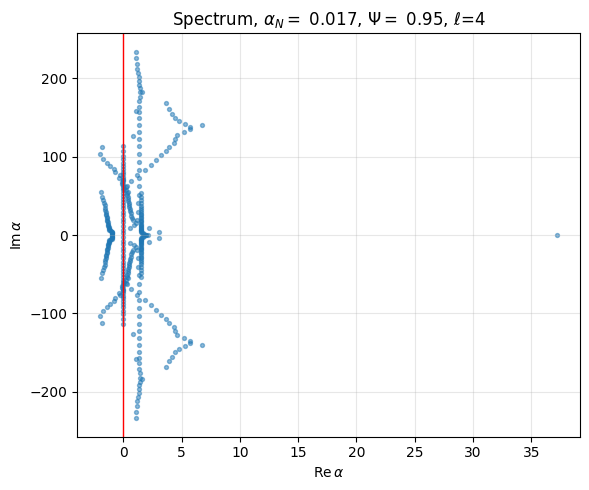

In [346]:
###########################################################################
##### Solve the eigenvalue problem and plot the spectrum
###########################################################################

al=solve(M)
print("finite eigenvalues:",al.size," max Re(alpha):",np.max(al.real))
plt.figure(figsize=(6,5)); plt.scatter(al.real,al.imag,s=8,alpha=.5); plt.axvline(0,c='r',lw=1)
plt.xlabel(r'$\mathrm{Re}\,\alpha$'); plt.ylabel(r'$\mathrm{Im}\,\alpha$')
plt.title(rf'Spectrum, $\alpha_N = $ {ALN_TEST}, $\Psi = $ {PSI_N_TEST}, $\ell$={L_TEST}')

plt.grid(alpha=.3)
# plt.xlim(-10, 10)
plt.tight_layout(); plt.show()

In [ ]:
###########################################################################
##### Filtering: keep only the eigenvalues that are present in multiple resolutions
###########################################################################

def matched_eigs(al1, al2, rtol=5e-2):
    keep=[]
    for a in al1:
        d=np.min(np.abs(al2-a)/(np.abs(a)+1e-12))
        if d<rtol: keep.append(a)
    return np.array(keep)

# solve at two different grid resolutions and compare eigenvalues
res_scale = 2
M1=build(bg, L=L_TEST, n2_core=60,           n2_raref = 20,           n1=60)
M2=build(bg, L=L_TEST, n2_core=60*res_scale, n2_raref = 20*res_scale, n1=60*res_scale)

a1=solve(M1); a2=solve(M2)
persistent=matched_eigs(a1,a2) # eigenvalues that are present in BOTH resolutions

print(f"N1 finite: {a1.size}, N2 finite: {a2.size}, persistent: {persistent.size}")
if persistent.size:
    order=np.argsort(-persistent.real)
    print("persistent modes, largest Re(alpha) first:")
    for a in persistent[order][:8]: print(f"   alpha = {a.real:+.4f} {a.imag:+.4f}i")


N1 finite: 353, N2 finite: 713, persistent: 335
persistent modes, largest Re(alpha) first:
   alpha = +37.2234 +0.0000i
   alpha = +6.7475 -139.7469i
   alpha = +6.7475 +139.7469i
   alpha = +5.7068 +134.6553i
   alpha = +5.7068 -134.6553i
   alpha = +5.6744 +137.5266i
   alpha = +5.6744 -137.5266i
   alpha = +5.2445 +141.0075i


coarse=362  fine=722  persistent=344  max Re(α)=0.4680  n_unstable=206


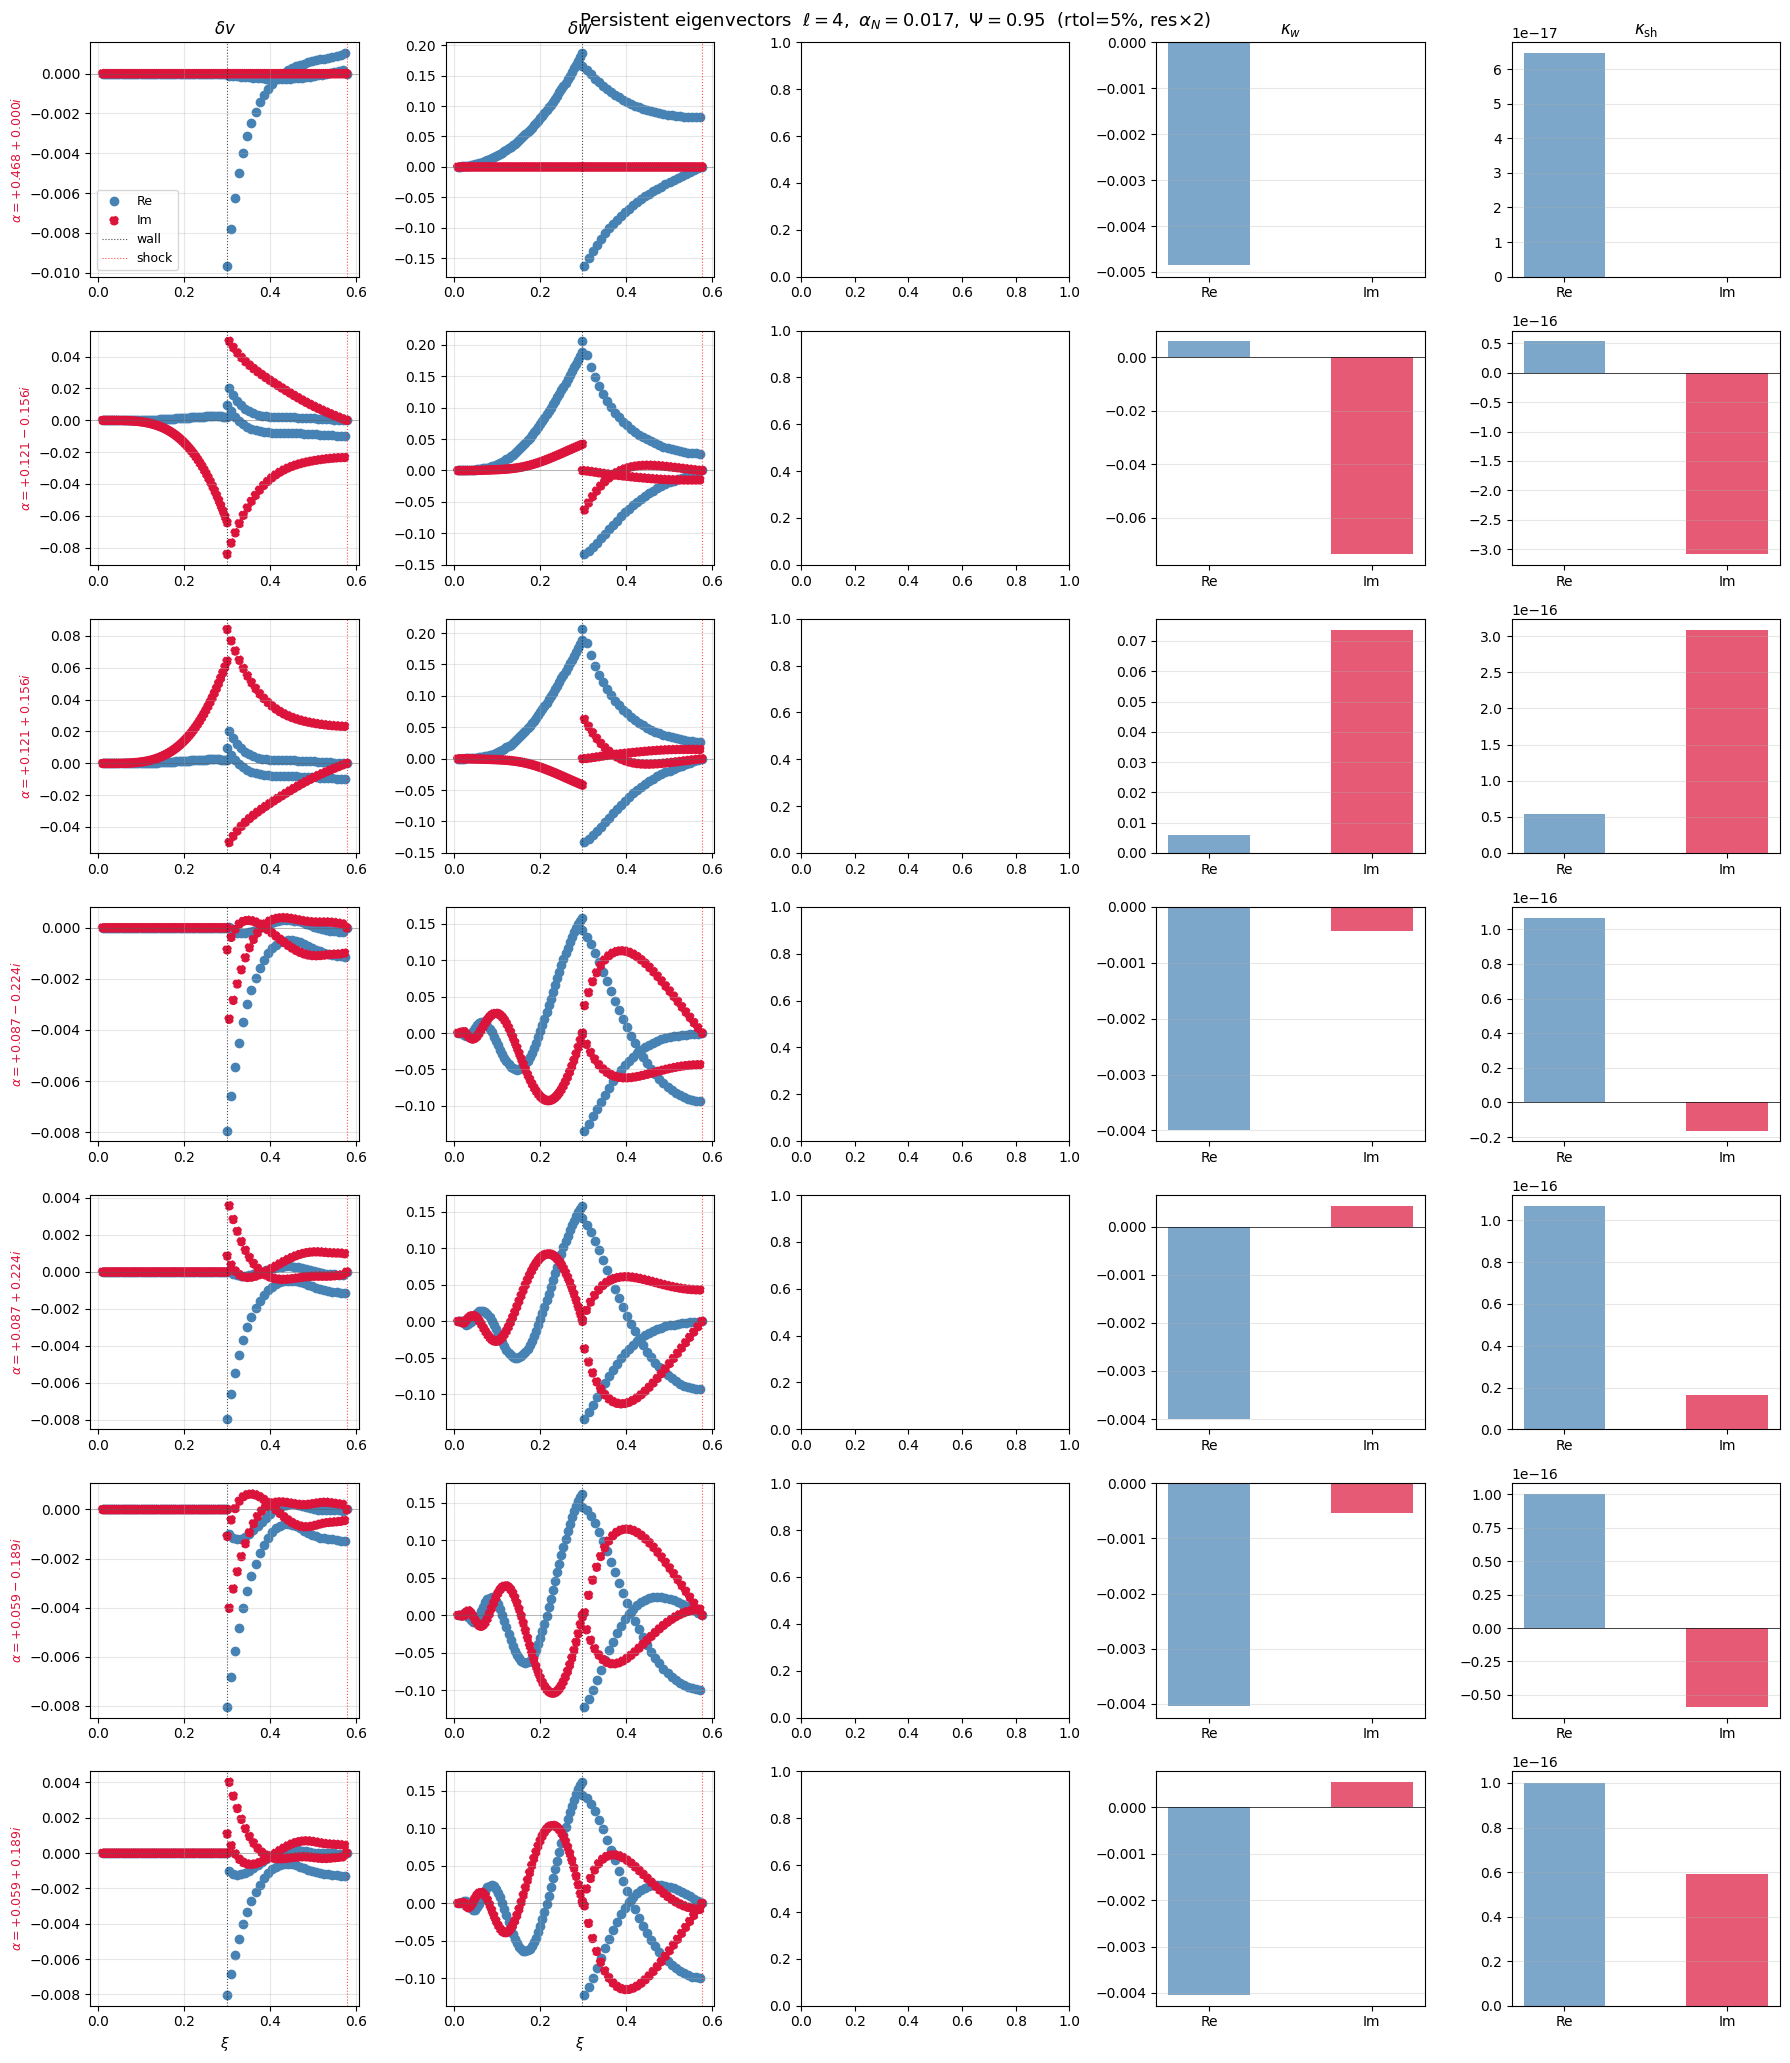

In [338]:
# ── Eigenvector visualization ──────────────────────────────────────
ELL_VIZ  = 4
N_MODES  = 7
RES_SCALE = 2

FIELD_LABELS = [r'$\delta v$', r'$\delta w$', r'$\delta N$']
SURF_LABELS  = [r'$\kappa_w$', r'$\kappa_\mathrm{sh}$']

# ── build two grids ────────────────────────────────────────────────
M1 = build(bg, L=ELL_VIZ, n2_core=60,           n2_raref=40,           n1=60)
M2 = build(bg, L=ELL_VIZ, n2_core=60*RES_SCALE, n2_raref=40*RES_SCALE, n1=60*RES_SCALE)
assert M1['filled'].all() and M2['filled'].all()

# ── solve both grids for eigenvalues AND eigenvectors ──────────────
a1, v1 = eig(M1['A'], M1['B'])
a2, v2 = eig(M2['A'], M2['B'])

# ── filter to finite only ──────────────────────────────────────────
fin1 = np.isfinite(a1);  a1 = a1[fin1];  v1 = v1[:, fin1]
fin2 = np.isfinite(a2);  a2 = a2[fin2];  v2 = v2[:, fin2]

# ── match persistent modes (keep coarse eigenvalue + fine eigenvector) ─
def matched_eigs_with_vecs(al1, vecs1, al2, vecs2, rtol=5e-2):
    """Return (persistent_alphas, corresponding_fine_vecs)."""
    keep_al, keep_vec = [], []
    for i, a in enumerate(al1):
        dists = np.abs(al2 - a) / (np.abs(a) + 1e-12)
        j = np.argmin(dists)
        if dists[j] < rtol:
            keep_al.append(a)
            keep_vec.append(vecs2[:, j])   # use fine-grid vector
    return np.array(keep_al), np.array(keep_vec).T  # vecs shape (N, n_persistent)

alphas, vecs = matched_eigs_with_vecs(a1, v1, a2, v2)
print(f"coarse={a1.size}  fine={a2.size}  persistent={alphas.size}  "
      f"max Re(α)={alphas.real.max() if alphas.size else float('nan'):.4f}  "
      f"n_unstable={(alphas.real > 0).sum()}")

# sort most unstable first
order  = np.argsort(-alphas.real)
alphas = alphas[order]
vecs   = vecs[:, order]

n_plot = min(N_MODES, alphas.size)
if n_plot == 0:
    print("No persistent modes found — nothing to plot.")
else:
    # use M1 (coarse) grid for plotting — M2 grid is too dense to reshape simply
    NF  = M1['NF'];  Ng = len(M1['xi']);  xi = M1['xi']
    ikw = M1['ikw']; iksh = M1['iksh']

    fig, axes = plt.subplots(n_plot, 5, figsize=(18, 3*n_plot))
    if n_plot == 1: axes = axes[np.newaxis, :]   # ensure 2D even for 1 row
    fig.suptitle(
        rf'Persistent eigenvectors  $\ell={ELL_VIZ},\ \alpha_N={ALN_TEST},\ \Psi={PSI_N_TEST}$'
        rf'  (rtol=5%, res$\times${RES_SCALE})',
        fontsize=13
    )

    for row in range(n_plot):
        alpha = alphas[row]

        # re-solve on coarse grid to get correctly-sized eigenvector for plotting
        idx   = np.argmin(np.abs(a1 - alpha) / (np.abs(alpha) + 1e-12))
        vec   = v1[:, idx].copy()

        # fix overall phase
        vec  /= (vec[np.argmax(np.abs(vec))] / np.abs(vec[np.argmax(np.abs(vec))]))

        bulk = vec[:NF*Ng].reshape(Ng, NF)
        kw   = vec[ikw];  ksh = vec[iksh]

        for col in range(2): #range(NF):
            ax = axes[row, col]
            ax.scatter(xi, bulk[:, col].real, color='steelblue', label='Re')
            ax.scatter(xi, bulk[:, col].imag, color='crimson',   label='Im', ls='--')
            ax.axvline(bg['xi_w'],  ls=':', c='k', lw=0.8, alpha=0.7, label='wall')
            ax.axvline(bg['xi_sh'], ls=':', c='r', lw=0.8, alpha=0.7, label='shock')
            ax.axhline(0, c='k', lw=0.5, alpha=0.3)
            ax.grid(alpha=0.3)
            if row == 0:      ax.set_title(FIELD_LABELS[col], fontsize=12)
            if row == n_plot-1: ax.set_xlabel(r'$\xi$')
            if col == 0:
                color = 'crimson' if alpha.real > 0 else 'steelblue'
                ax.set_ylabel(rf'$\alpha={alpha.real:+.3f}{alpha.imag:+.3f}i$',
                              fontsize=9, color=color)
            if row == 0 and col == 0: ax.legend(fontsize=9)

        for col, (label, val) in enumerate(zip(SURF_LABELS, [kw, ksh]), start=NF):
            ax = axes[row, col]
            ax.bar(['Re', 'Im'], [val.real, val.imag],
                   color=['steelblue', 'crimson'], alpha=0.7, width=0.5)
            ax.axhline(0, c='k', lw=0.5)
            ax.grid(alpha=0.3, axis='y')
            if row == 0: ax.set_title(label, fontsize=12)

    plt.tight_layout()
    plt.show()

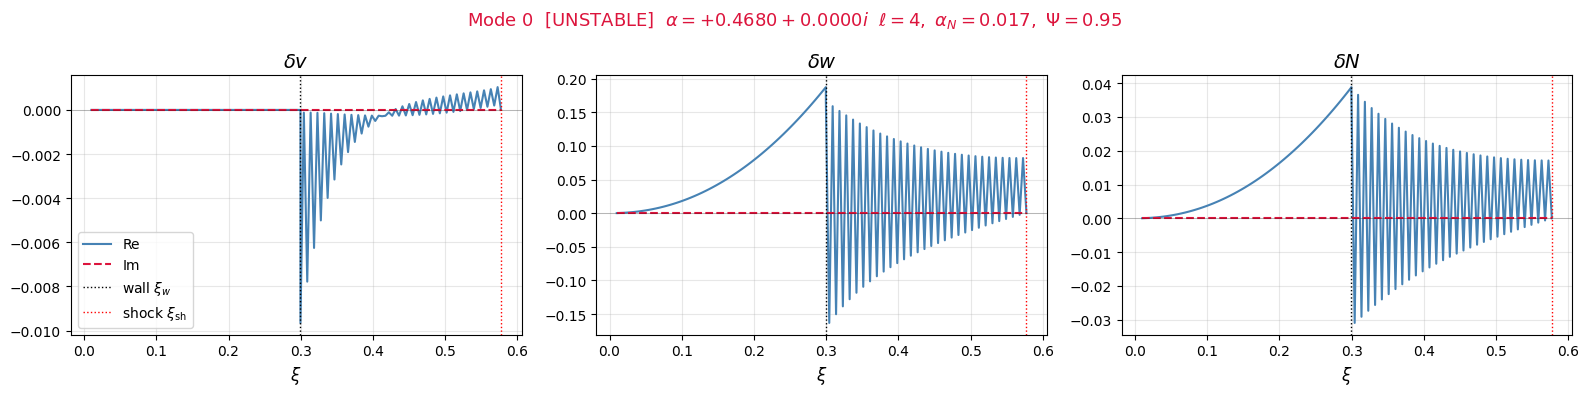

  κ_w  = -0.0049 -0.0000i
  κ_sh = +0.0000 -0.0000i


In [ ]:
# ── Single-mode eigenvector plot (larger) ─────────────────────────
MODE_IDX = 0   # ← change this to inspect different modes (0 = most unstable)

alpha = alphas[MODE_IDX]
idx   = np.argmin(np.abs(a1 - alpha) / (np.abs(alpha) + 1e-12))
vec   = v1[:, idx].copy()

# fix overall phase
vec  /= (vec[np.argmax(np.abs(vec))] / np.abs(vec[np.argmax(np.abs(vec))]))

NF  = M1['NF'];  Ng = len(M1['xi']);  xi = M1['xi']
bulk = vec[:NF*Ng].reshape(Ng, NF)

color = 'crimson' if alpha.real > 0 else 'steelblue'
stability = 'UNSTABLE' if alpha.real > 0 else 'stable'

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(
    rf'Mode {MODE_IDX}  [{stability}]  $\alpha = {alpha.real:+.4f}{alpha.imag:+.4f}i$'
    rf'  $\ell={ELL_VIZ},\ \alpha_N={ALN_TEST},\ \Psi={PSI_N_TEST}$',
    fontsize=13, color=color
)


for col, (ax, label) in enumerate(zip(axes, FIELD_LABELS)):
    ax.plot(xi, bulk[:, col].real, color='steelblue', lw=1.5, label='Re')
    ax.plot(xi, bulk[:, col].imag, color='crimson',   lw=1.5, label='Im', ls='--')
    ax.axvline(bg['xi_w'],  ls=':', c='k', lw=1.0, label=r'wall $\xi_w$')
    ax.axvline(bg['xi_sh'], ls=':', c='r', lw=1.0, label=r'shock $\xi_\mathrm{sh}$')
    ax.axhline(0, c='k', lw=0.5, alpha=0.3)
    ax.set_title(label, fontsize=14)
    ax.set_xlabel(r'$\xi$', fontsize=12)
    ax.grid(alpha=0.3)
    if col == 0:
        ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"  κ_w  = {vec[M1['ikw']].real:+.4f} {vec[M1['ikw']].imag:+.4f}i")
print(f"  κ_sh = {vec[M1['iksh']].real:+.4f} {vec[M1['iksh']].imag:+.4f}i")

## Run a sweep over different values of $\ell$ and plot the resulting spectrum 

found matching solution for LTE wall velocity:  0.29958806514240965
has_back=False  tail=— (deflagration)  wall=0.2996  shock=0.5774
ℓ= 4: coarse=353  fine=713  persistent=335  max Re(α)=37.2234  n_unstable=202
ℓ= 8: coarse=353  fine=713  persistent=336  max Re(α)=37.2234  n_unstable=225
ℓ=16: coarse=353  fine=713  persistent=336  max Re(α)=37.2234  n_unstable=221
ℓ=32: coarse=353  fine=713  persistent=338  max Re(α)=37.2234  n_unstable=221


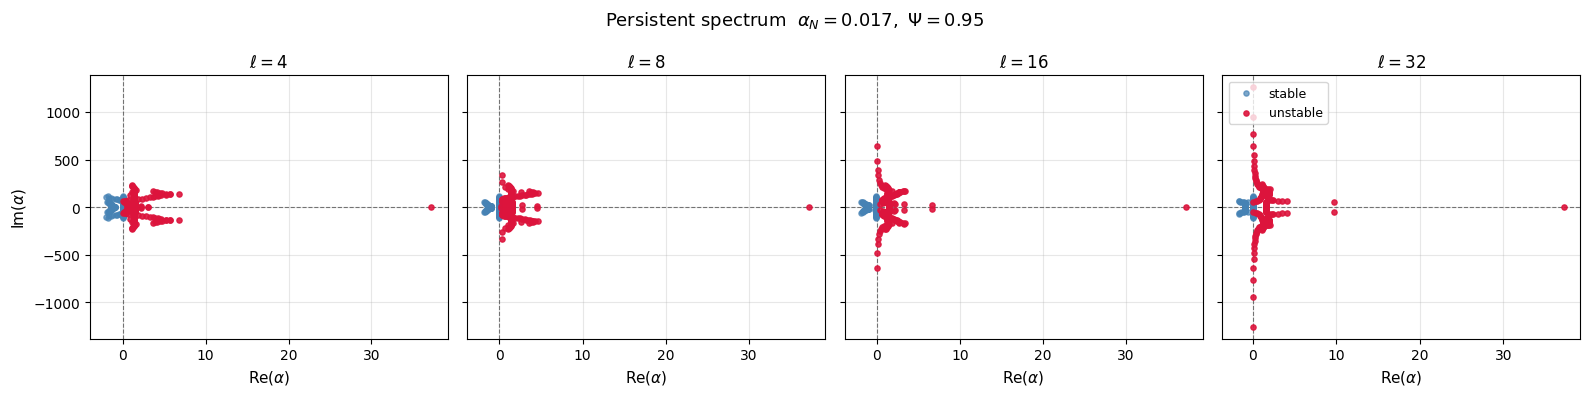

In [335]:

ALN_TEST = 0.017
PSI_N_TEST = 0.95

ELL_LIST   = [4, 8, 16, 32]
RES_SCALE  = 2

def matched_eigs(al1, al2, rtol=5e-2):
    keep = []
    for a in al1:
        d = np.min(np.abs(al2 - a) / (np.abs(a) + 1e-12))
        if d < rtol: keep.append(a)
    return np.array(keep)

# ── shared background (built once) ────────────────────────────────
bg = background_from_hydro(alN=ALN_TEST, psiN=PSI_N_TEST)
tail = f"{bg['xi_tail']:.4f}" if bg['has_back'] else '— (deflagration)'
print(f"has_back={bg['has_back']}  tail={tail}  wall={bg['xi_w']:.4f}  shock={bg['xi_sh']:.4f}")

# ── sweep ℓ, resolve at two grids, keep only persistent modes ─────
spectra = {}
for ell in ELL_LIST:
    M1 = build(bg, L=ell, n2_core=60,              n2_raref=20,              n1=60)
    M2 = build(bg, L=ell, n2_core=60*RES_SCALE,    n2_raref=20*RES_SCALE,    n1=60*RES_SCALE)
    assert M1['filled'].all(), f"ℓ={ell} M1: unfilled rows: {np.where(~M1['filled'])[0]}"
    assert M2['filled'].all(), f"ℓ={ell} M2: unfilled rows: {np.where(~M2['filled'])[0]}"
    a1 = solve(M1); a2 = solve(M2)
    persistent = matched_eigs(a1, a2)
    spectra[ell] = persistent
    print(f"ℓ={ell:>2d}: coarse={a1.size}  fine={a2.size}  persistent={persistent.size}  "
          f"max Re(α)={persistent.real.max() if persistent.size else float('nan'):.4f}  "
          f"n_unstable={(persistent.real > 0).sum()}")

# ── plot persistent modes only ────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
fig.suptitle(rf'Persistent spectrum  $\alpha_N={ALN_TEST},\ \Psi={PSI_N_TEST}$', fontsize=13)

for ax, ell in zip(axes, ELL_LIST):
    ev = spectra[ell]
    stable   = ev[ev.real <= 0]
    unstable = ev[ev.real >  0]
    ax.scatter(stable.real,   stable.imag,   s=14, alpha=0.7, color='steelblue', label='stable',   zorder=3)
    ax.scatter(unstable.real, unstable.imag, s=14, alpha=0.9, color='crimson',   label='unstable',  zorder=4)
    ax.axvline(0, color='k', lw=0.8, ls='--', alpha=0.5)
    ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
    ax.set_title(rf'$\ell = {ell}$', fontsize=12)
    ax.set_xlabel(r'Re$(\alpha)$', fontsize=11)
    ax.grid(alpha=0.3)
    if ax is axes[0]:
        ax.set_ylabel(r'Im$(\alpha)$', fontsize=11)
    if ax is axes[-1]:
        ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

## Validation checklist
# stuff to check 

3. **Junction signs:** cross-check assembled coefficients against the bc equations.
4. **High-l vs megevand–membiela paper:** $\mathrm{Re}\,\alpha$ should go probably go linear in l with the
   planar Landau slope.
